# Web Scraping

Automated gathering of data from web pages.

---

## 1. Rules-Based Scraping: Static Web Pages

### Submitting requests

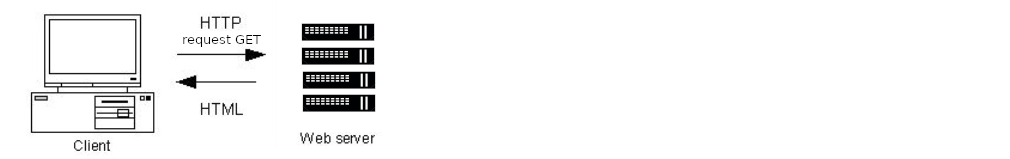

In [1]:
import requests

# pip install urllib

In [21]:
response = requests.get('http://neuefische.de')

**Available response attributes:**  
- response.**status_code** &rightarrow; was the request successful?
- response.url &rightarrow; the responding URL
- response.encoding &rightarrow; which text encoding is used?
- response.headers &rightarrow; the site's header
- response.**text** &rightarrow; the text which we are interested in

In [22]:
response.status_code

200

**The status code**
- 200 means that the request was valid and we got what we asked for.

- Everything with 400 means that we made a mistake or are not authorized &rightarrow; *Client error*
  - 404: Page not found

- Everything with 500 means that there is an error on the server side &rightarrow; *Server error*

**The text**

In [23]:
html_text = response.text

In [24]:
html_text

'<!DOCTYPE html><html lang="de"><head><meta charSet="utf-8"/><meta name="viewport" content="width=device-width, initial-scale=1, interactive-widget=resizes-content"/><meta name="twitter:card" content="summary_large_image"/><meta name="twitter:site" content="@neuefische"/><meta property="og:type" content="website"/><meta property="og:locale" content="de"/><meta property="og:site_name" content="Neue Fische"/><meta name="format-detection" content="telephone=no"/><title>Coding und KI Weiterbildungen live online auf Deutsch und Englisch | neue fische</title><meta name="robots" content="index,follow"/><meta name="description" content="Coding Bootcamps und IT-Schulungen auf Deutsch und Englisch live online."/><link rel="alternate" hrefLang="x-default" href="https://www.neuefische.de"/><link rel="alternate" hrefLang="de" href="https://www.neuefische.de"/><link rel="alternate" hrefLang="en" href="https://www.neuefische.de/en"/><meta property="og:title" content="Coding und KI Weiterbildungen liv

#### Filling web forms

You sometimes want to get the html response after filling out a web form, e.g.  
https://datascience.stackexchange.com/  
when you search for e.g. "regex"

In [25]:
# https://datascience.stackexchange.com/search?q=regex
# can be requested by:
# html_text = requests.get("https://datascience.stackexchange.com/search?q=regex").text

# or more professional like this:

url = "https://datascience.stackexchange.com/"


form_values = {'q':'regex', 'pagesize':100}
response = requests.get(url, form_values)
# html_text = response.text

In [26]:
response.url

'https://datascience.stackexchange.com/?q=regex&pagesize=100'

In [27]:
html_text

'<!DOCTYPE html><html lang="de"><head><meta charSet="utf-8"/><meta name="viewport" content="width=device-width, initial-scale=1, interactive-widget=resizes-content"/><meta name="twitter:card" content="summary_large_image"/><meta name="twitter:site" content="@neuefische"/><meta property="og:type" content="website"/><meta property="og:locale" content="de"/><meta property="og:site_name" content="Neue Fische"/><meta name="format-detection" content="telephone=no"/><title>Coding und KI Weiterbildungen live online auf Deutsch und Englisch | neue fische</title><meta name="robots" content="index,follow"/><meta name="description" content="Coding Bootcamps und IT-Schulungen auf Deutsch und Englisch live online."/><link rel="alternate" hrefLang="x-default" href="https://www.neuefische.de"/><link rel="alternate" hrefLang="de" href="https://www.neuefische.de"/><link rel="alternate" hrefLang="en" href="https://www.neuefische.de/en"/><meta property="og:title" content="Coding und KI Weiterbildungen liv

BTW: For more general requests use `requests.post(url, form_values)`. Look [here](https://www.geeksforgeeks.org/get-post-requests-using-python/) for differences between `.get()` and `.post()`.  
Here is the [documentation](https://requests.readthedocs.io/en/latest/) of the requests library (with many more possibilities).  
I you want to download a huge amount of web pages, you might like as well `wget` or `curl`.

#### Beware

Some (commercial) web site owners frequently alter the html code and try to obsfucate the structure to complicate web scraping.

**Consider** that some web site owners have restrictions on web site crawling. You often can find these restrictions in robots.txt: (e.g. lyrics.com/robots.txt). Look [here](https://moz.com/learn/seo/robotstxt) for meanings.


If you want to scrape the same page several times, it is a good (faster) idea to set up a session first:  
`s = requests.Session()`  
You can then get content (several times) via  
`r = s.get('http://anywebpage.xy/')`

### HTML

When trying to find an information on a certain location of a web page, we need to have a overview of the site's structure. That's what *parsing* means. Web pages are usually written in html.  



html means *hypertext markup language*. It was defined for exchange of electronic texts.  
- *hypertext* because it contains more than just text, e.g. links (hyperlinks) to other electronic texts  
- *markup language*: distinct from the visible text, e.g. formatting or structuring information.

One of the most important key components of html are the so-called tags. They often come in pairs, opening tags (e.g.`<head>`) and closing ones (e.g. `</head>`), giving the text a structure.

```{html}
<!DOCTYPE html>
<html>
  <head>
    <title>This is a title</title>
  </head>
  <body>
    <div>
        <p>Hello world!</p>
    </div>
  </body>
</html>
```

#### Some frequently used tags

- html tag: `<html> ... </html>`; root of the document
- head tag: `<head>document description</head>`
- body tag: `<body>`; contains text, images, tables...  
- title tag: `<title>`
- heading tag: `<h1>`, `<h2>`, ...; denotes different levels of headings  
- paragraph tag: `<p>`  
- link tag: `<a href="https://..."> Statements... </a>`; links to local or remote sites  
- unordered list tag: `<ul> <li>item 1</li> <li>item 2</li> </ul>`
- ordered list tag: `<ol>`; the rest like above
- image tag: `<img src="path_to_image.png">`; doesn't have a closing tag
- span tag: `<span>`; defines a section in a document
- div tag: `<div>`; section that is styled with CSS

Find all tags [here](https://www.w3schools.com/TAgs/default.asp).

Some tags might have so-called **attributes**, like a
- *class attribute* like `<li class="some_class_name"> ... </li>` or an  
- *id attribute* like `<h1 id="myHeader">My Header</h1>`. They are a unique id for an HTML element and simplify search a lot.


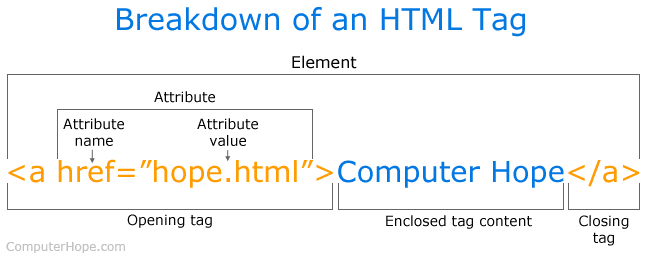

### BeautifulSoup

BeautifulSoup is a library which parses HTML and creates a tree structure of python objects that we can navigate through, extract information from, and edit. This makes life much easier than using regex only. 😀

#### Installation

In [ ]:
# using pip
#!pip install beautifulsoup4

#### Most important concepts of beautifulsoup

#### `find()` and `find_all()`

- `.find_all()` finds matching elements, while `.find()` finds the first.  


- The argument of `.find_all()` and `.find()` can contain
  - the tagname like `.find("header")`
  - the attribute value like `.find(class_="...")` or `.find_all(id="...")`
  - the attribute name: Use `id=True` to find any tags containing the `id="..."` attribute
  - `string=` to seach for a string within an element: `find_all(string="...")`
  - **or any combination.**
  - If you get an error, consider [this](https://www.crummy.com/software/BeautifulSoup/bs4/doc/#the-keyword-arguments) solution.

In [29]:
example_html_text = '''
<!DOCTYPE html>
<html>
  <head>
    <title>This is a title</title>
  </head>
  <body>
    <div>
        <p>Hello world!</p>
    </div>
  </body>
</html>
'''

In [28]:
from bs4 import BeautifulSoup
example_html_soup = BeautifulSoup(example_html_text, "html.parser")

In [30]:
example_html_soup.find("body").find("div").find("p").text

'Hello world!'

##### Alternative (shorter) notation

- Instead of `soup.find("tagname")` you can also use the `soup.tagname` notation, that means:
  - instead of chaining several `.find()`s you can use dots, e.g. `soup.body.h4.a...`

In [31]:
example_html_soup.body.div.p.text

'Hello world!'

##### Retrieving tag content / attribute value

- For retrieving the tag content of a certain element use the `.get_text()` attribute (or `string` or `text`),  
  - e.g. to retrieve "Web Development" in `<a href="/to/be/retrieved/">Web Development</a>` use `soup...a.get_text()`.


- For retrieving the attribute value use `soup.get("attribute_name")`.
  - e.g. to retrieve "/to/be/retrieved/" in `<a href="/to/be/retrieved/">Web Development</a>` use `soup.a.get("href")`
  - e.g. to retrieve "fb-customerchat" in `<div class="fb-customerchat">` use `soup.div.get("class_")`  
    **add an underscore** behind `class` (`class_`) to discriminate from the python keyword `class`.

In [32]:
example_html_soup.body.div.p.get_text()

'Hello world!'

##### Going up one level with `.parent`

- If you found your result and want to climb up the levels, `subsoup.parent` is your friend, leading you to `soup`.

In [35]:
subsoup = example_html_soup.body.div.p
subsoup.parent.parent

<body>
<div>
<p>Hello world!</p>
</div>
</body>

##### Further helpers

- beautifulsoup also accepts regular expressions to search for,  
  - e.g. `.find_all(re.compile("^b"))` to find all tags starting with a "b".
- There's much more to discover [here](https://www.crummy.com/software/BeautifulSoup/bs4/doc/).

#### Practical example

##### Import libraries, create the soup

In [36]:
# import libraries
import requests
from bs4 import BeautifulSoup
import re

In [37]:
# get html text
url = 'http://bbc.com/'
response = requests.get(url)
html_text = response.text

In [38]:
html_text

'<!DOCTYPE html><html lang="en-GB"><head><meta charSet="utf-8" data-next-head=""/><meta name="viewport" content="width=device-width" data-next-head=""/><title data-next-head="">BBC Home - Breaking News, World News, US News, Sports, Business, Innovation, Climate, Culture, Travel, Video &amp; Audio</title><meta name="page.section" content="Home" data-next-head=""/><meta property="og:title" content="BBC Home - Breaking News, World News, US News, Sports, Business, Innovation, Climate, Culture, Travel, Video &amp; Audio" data-next-head=""/><meta name="twitter:title" content="BBC Home - Breaking News, World News, US News, Sports, Business, Innovation, Climate, Culture, Travel, Video &amp; Audio" data-next-head=""/><meta name="description" content="Visit BBC for trusted reporting on the latest world and US news, sports, business, climate, innovation, culture and much more." data-next-head=""/><meta property="og:description" content="Visit BBC for trusted reporting on the latest world and US n

In [39]:
# convert html to beautiful soup object
soup = BeautifulSoup(html_text, "html.parser")

Find differences in BeautifulSoup parsers [here](https://www.crummy.com/software/BeautifulSoup/bs4/doc/#differences-between-parsers).

##### Inspect html code in the soup ...

In [40]:
# you can also print soup w/o prettify but without indentation
print(soup.prettify())

<!DOCTYPE html>
<html lang="en-GB">
 <head>
  <meta charset="utf-8" data-next-head=""/>
  <meta content="width=device-width" data-next-head="" name="viewport"/>
  <title data-next-head="">
   BBC Home - Breaking News, World News, US News, Sports, Business, Innovation, Climate, Culture, Travel, Video &amp; Audio
  </title>
  <meta content="Home" data-next-head="" name="page.section"/>
  <meta content="BBC Home - Breaking News, World News, US News, Sports, Business, Innovation, Climate, Culture, Travel, Video &amp; Audio" data-next-head="" property="og:title"/>
  <meta content="BBC Home - Breaking News, World News, US News, Sports, Business, Innovation, Climate, Culture, Travel, Video &amp; Audio" data-next-head="" name="twitter:title"/>
  <meta content="Visit BBC for trusted reporting on the latest world and US news, sports, business, climate, innovation, culture and much more." data-next-head="" name="description"/>
  <meta content="Visit BBC for trusted reporting on the latest world a

##### ... or in the browser ...

1. right click on an element on the web page: `inspect` (Safari: `Cmd+Option+I`)
2. hover over either the code or the web content
3. look which html code and which content belongs together to identify the structure  

In this example we want to find headlines of category "h2" with a specific class_ name.  

In [41]:
subsoup = soup.find_all(class_="sc-fa53feb6-0 bnwbbp")

##### ... and extract the desired information

In [42]:
headlines = []
for elm in subsoup:
    for line in elm.text.splitlines():
        if len(hl := line.strip()) > 15 and hl.count(' ') > 1:
            headlines.append(hl)


In [43]:
headlines

['Alberta separatists say they have enough signatures to trigger independence referendumOrganisers have filed a formal petition, but it remains to be seen whether Albertans will end up voting on seceding from Canada. Dolly Parton cancels Las Vegas residency over health issuesOne injured after plane hits truck while landing in NewarkBritney Spears pleads guilty to reckless driving after arrest',
 "What is the hantavirus that has been confirmed on an Atlantic cruise ship? While rare, the disease can be transmitted to humans through inhalation of airborne particles from dried rodent droppings.'Don't forget about Ukraine', says charityUS strikes Iranian fast boats as Iran attacks UAE oil facility 'Elephant in the room' Trump looms over European attempt at unity",
 'British pubs closing at a rate of almost two per day in 2026The British Beer and Pub Association says 161 pubs have closed in the first three months of this year.GameStop makes $55.5bn takeover offer for eBaySamsung family pays 

In [ ]:
import os
if os.path.exists('data_exchange/headlines.txt'):
    os.remove('data_exchange/headlines.txt')
if not os.path.exists('data_exchange'):
    os.mkdir('data_exchange')

with open('./data_exchange/headlines.txt', 'w') as f:
    for line in headlines:
        f.write(f"{line}\n")

---

## 2. Rules-Based Scraping: Dynamic Web Pages

Web pages can consist of
1. html (the skeleton of a website)
2. css code (controls the appearance of a website)
3. javascript (expansion with dynamic functions)  


Many web pages are dynamic, that means their content is not fixed HTML code but is generated on the fly, e.g. using JavaScript. Those rendered content cannot be scraped by BeautifulSoup. More powerful but also more complex libraries like [selenium](https://www.selenium.dev/), [Puppeteer](https://pptr.dev/) or [Playwright](https://playwright.dev/) that remote control a headless browser are required here.  

(If you want to inspect how a web page looks without JavaScript: Select *false* for *javascript.enabled* in *about:config* when using firefox.)

The web scraping scripts need to be individually tailored to the specific webpage. Use right click and "inspect" to find class names to simulate mouse clicks, etc.

### Installation   

First install required libraries  
```pip install playwright numpy```  
Then install the firefox interface  
```playwright install firefox```  
```playwright install-deps```  

### Run this code to scrape nasdaq.com

```
import numpy as np
from playwright.sync_api import sync_playwright
playwright = sync_playwright().start()

browser = playwright.firefox.launch(headless=False)  # headless=True means without opening visible browser instance

# Start the browser
page = browser.new_page()
url = "https://www.nasdaq.com/market-activity/index/comp/historical"
page.goto(url)

# "Inspect" the page and shimmy through the "I Accept button". This leads to the button we need to click.
page.locator("#onetrust-accept-btn-handler").click()

# Wait a random amount of milliseconds to obsfucate automation
page.wait_for_timeout(np.random.randint(502, 1989))

# Some individual commands
page.keyboard.press('Space')
page.wait_for_selector('.simple-table-template', state='attached')
data = page.locator('.simple-table-template')
result = data.text_content()

# Save visible data as a csv file
out = np.array(result.split()).reshape(-1,5)
with open('output.csv', 'w') as f:
    np.savetxt(f, out, delimiter=',', fmt='%s')
```

### Record user interaction  

Playwright can also be used to record user action performed in a browser.  
1. Start ```playwright codegen -b firefox <URL>```  
2. Interact with your browser.
3. The actions will be transcoded in a python script.
4. Edit this script to your needs an run it to scrape the needed data.  


---

## 3. Semantic/Generative Scraping

Rules based scraping is the traditional approach. It breaks when the websites change.  
In generative scraping you tell the took what you want rather than where it is and you make use of the tools "intelligence".  

There are tools like [Jina](https://jina.ai), [Firecrawl](), or [ScrapeGraphAI]().  
Jina, e.g. works by simply prepending https://r.jina.ai/ in front of the web page in question to get the output, e.g. from [BBC](https://r.jina.ai/https://bbc.com).

Furthermore there are also MCP servers available for webscraping like [Scrapling](https://github.com/D4Vinci/Scrapling) or [Playwright-MCP](https://github.com/microsoft/playwright-mcp) which are controlled by an LLM.

---

## 4. Web "scraping" using an API

API (Application Programming Interface) is a concept used to describe – essentially – a piece of intermediary software (the interface) that facilitates communication between 2 other pieces of software (the applications).

Here, we mean **Web** APIs. 

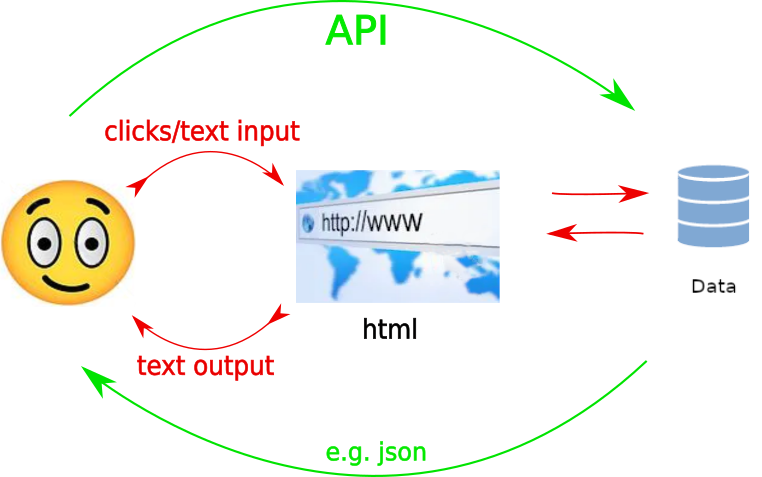

#### What makes a web API better than scraping? 

- Interface is not meant for humans but for machines. This refers both, to  
    - requests (=> well defined way how to ask for information)
    - and to data delivery (=> provides data in a **more machine-readable format**, mostly json) 
- For larger data providers there are often  
    - helper libraries  
    - documentation and examples
    - clear terms and conditions about what is allowed
- From the point of view of the provider, APIs
    - create visibility (e.g. for a hotel operator whose vacant rooms are to be found by a meta search engine)
    - ...

#### What is a REST API?

REST (**RE**presentational **S**tate **T**ransfer) means an [agreement](https://konghq.com/blog/learning-center/what-is-restful-api) about the protocol how the API works.  
It is the de facto standard for developing web APIs.  
REST APIs usually refer to http endpoints rather than to function calls.  

They repurpose the http protocol and allow for the CRUD operations (create, read, update delete).  

#### Simple Example

In [44]:
"""
Berlin public transport API
"""

import requests

BASE_URL = 'https://v6.vbb.transport.rest'

# find a station
name = 'moritzplatz'
url = f"{BASE_URL}/locations?query={name}"
station_id = requests.get(url, timeout=1).json()[0]['id']  # https://stackoverflow.com/questions/70917108/python-requests-get-only-responds-if-adding-a-time-out


# look up departures
print(f'\nNext connections from U {name.capitalize()}:\n')

url = f'{BASE_URL}/stops/{station_id}/departures?duration={10}'

j = requests.get(url, timeout=10).json()

for e in j['departures']:
    print(e['plannedWhen'][11:-9], '  ', e['line']['name'], e['direction'])


Next connections from U Moritzplatz:

10:45    M29 U Hermannplatz
10:51    M29 U Hermannplatz
10:53    U8 Hermannstraße
10:53    U8 Wittenau
10:57    M29 U Hermannplatz
10:58    M29 Grunewald, Roseneck
10:58    U8 Hermannstraße
10:58    U8 Paracelsus-Bad
11:03    U8 Hermannstraße
11:03    U8 Wittenau


In [45]:
url

'https://v6.vbb.transport.rest/stops/900013101/departures?duration=10'

## Ressources

- [Beautiful Soup documentation](https://www.crummy.com/software/BeautifulSoup/bs4/doc/)  
- [Video on retrieving job ads with BS](https://www.youtube.com/watch?v=XVv6mJpFOb0&t=1552s)  
- [How to submit forms (e.g. passwords)](https://realpython.com/python-web-scraping-practical-introduction/)
- [How to avoid getting blacklisted during web scraping](https://www.scrapehero.com/how-to-prevent-getting-blacklisted-while-scraping/)  
- Other web scrapers: [selenium](https://selenium-python.readthedocs.io/), [scrapy](https://scrapy.org/), [Puppeteer](https://pptr.dev/), [Playwright](https://playwright.dev/)  
- [A nice scraping tool](https://www.scraperapi.com/)  
- [Neuefische video on beautifulsoup](https://www.youtube.com/watch?v=HMSe8WTNmFg)
- Search APIs just be [consulting the internet](https://letmegooglethat.com/?q=API) (often with example code)
- List of web APIs [[1](https://apislist.com/), [2](https://pypi.org), [3](https://rapidapi.com/hub)]
- [Example](https://www.youtube.com/watch?v=BmHKb0kLGtA) how to scrape from Wikipedia   